In [244]:
!pip install pandas
!pip install numpy
!pip install seaborn

In [245]:
import pandas as pd
import numpy as np 
import seaborn as sns

In [246]:
#read in the uber dataset 
df1=pd.read_csv("uber.csv")


# Objective: Data Wrangling/cleaning the dataset

In [247]:
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967153,40.767158,-73.963659,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [248]:
#the first column: Unname:0 is just a junk column so I will remove it. Additionally, the 'key' column also lacks purpose.
df1.rename(columns={'Unnamed: 0': 'Unnamed'},inplace=True)
df1.drop(columns=['Unnamed'], axis=1,inplace=True)
df1.drop(columns=['key'],axis=1,inplace=True)
df1.columns


Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [249]:
#checked that there were only 2 incidents of NaN values, so I decided to drop the rows.
df1.head()
df1.isnull().sum()
df1=df1.dropna()

In [250]:

#Fare Amount must be between 2 and 200 dollars
df1=df1[(df1['fare_amount'].between(2,200))
# longitude values must be within -180 and +180
&(df1['pickup_longitude'].between(-180,180))
&(df1['dropoff_longitude'].between(-180,180))
#Latitude values must be within -90 and +90
&(df1['pickup_latitude'].between(-90,90))
&(df1['dropoff_latitude'].between(-90,90))
#passenger count must not be 0 and the max should be upto 7
&(df1['passenger_count'].between(1,7))]
df1.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,199246.000000,199246.000000,199246.000000,199246.000000,199246.000000,199246.000000
mean,11.359755,-72.505215,39.919745,-72.515445,39.924056,1.689459
std,9.750828,10.438711,6.125951,10.399495,6.112495,1.305408
min,2.500000,-93.824668,-74.015515,-75.458979,-74.015750,1.000000
25%,6.000000,-73.992063,40.734798,-73.991409,40.733830,1.000000
50%,8.500000,-73.981825,40.752584,-73.980094,40.753042,1.000000
75%,12.500000,-73.967165,40.767155,-73.963664,40.767995,2.000000
max,200.000000,40.808425,48.018760,40.831932,45.031598,6.000000


In [251]:
#the dateTime column was converted to the dateTime format  
df1['pickup_datetime']=pd.to_datetime(df1['pickup_datetime'])
#new columns are made for future model usage
df1['hour'] = df1['pickup_datetime'].dt.hour
df1['day_of_week'] = df1['pickup_datetime'].dt.dayofweek
df1['month'] = df1['pickup_datetime'].dt.month
df1['year'] = df1['pickup_datetime'].dt.year
# dropping the "pickup_datetime" column as it serves no purpose now.
df1=df1.drop('pickup_datetime',axis=1)

In [252]:
df1.info()
df1.describe()
df1.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
Index: 199246 entries, 0 to 199999
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        199246 non-null  float64
 1   pickup_longitude   199246 non-null  float64
 2   pickup_latitude    199246 non-null  float64
 3   dropoff_longitude  199246 non-null  float64
 4   dropoff_latitude   199246 non-null  float64
 5   passenger_count    199246 non-null  int64  
 6   hour               199246 non-null  int32  
 7   day_of_week        199246 non-null  int32  
 8   month              199246 non-null  int32  
 9   year               199246 non-null  int32  
dtypes: float64(5), int32(4), int64(1)
memory usage: 13.7 MB


fare_amount          0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day_of_week          0
month                0
year                 0
dtype: int64

In [253]:
from math import radians, cos, sin, asin, sqrt
#The harversine formula is useful for clacluating the distance between points
#given that the longitude and latitude points are known between the start and the end position
#Earth's radius
radius=6371
df1['distance_km'] = 2 * radius * np.arcsin(np.sqrt(
    np.sin((np.radians(df1['dropoff_latitude']) - np.radians(df1['pickup_latitude'])) / 2) ** 2 +
    np.cos(np.radians(df1['pickup_latitude'])) *
    np.cos(np.radians(df1['dropoff_latitude'])) *
    np.sin((np.radians(df1['dropoff_longitude']) - np.radians(df1['pickup_longitude'])) / 2) ** 2
))


In [254]:
#since the distance metric has been calculated, we no longer need the latitude 
#and longitude columns: 
df1=df1.drop(['dropoff_latitude','pickup_latitude','dropoff_longitude','pickup_longitude'],axis=1)

In [255]:
#how the dataset looks now: 
df1.head()
df1.info()
df1.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 199246 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   fare_amount      199246 non-null  float64
 1   passenger_count  199246 non-null  int64  
 2   hour             199246 non-null  int32  
 3   day_of_week      199246 non-null  int32  
 4   month            199246 non-null  int32  
 5   year             199246 non-null  int32  
 6   distance_km      199246 non-null  float64
dtypes: float64(2), int32(4), int64(1)
memory usage: 9.1 MB


,fare_amount,passenger_count,hour,day_of_week,month,year,distance_km
count,199246.000000,199246.000000,199246.000000,199246.000000,199246.000000,199246.000000,199246.000000
mean,11.359755,1.689459,13.492873,3.049286,6.283464,2011.743664,20.321312
std,9.750828,1.305408,6.516009,1.946758,3.438481,1.859071,376.857429
min,2.500000,1.000000,0.000000,0.000000,1.000000,2009.000000,0.000000
25%,6.000000,1.000000,9.000000,1.000000,3.000000,2010.000000,1.215440
50%,8.500000,1.000000,14.000000,3.000000,6.000000,2012.000000,2.122001
75%,12.500000,2.000000,19.000000,5.000000,9.000000,2013.000000,3.875805
max,200.000000,6.000000,23.000000,6.000000,12.000000,2015.000000,8782.898606


In [256]:
#the Uber drive distance should be less than 60 kilometres
df1=df1[df1['distance_km'].between(0.01,60)]
df1.describe()

,fare_amount,passenger_count,hour,day_of_week,month,year,distance_km
count,192689.000000,192689.000000,192689.000000,192689.000000,192689.000000,192689.000000,192689.000000
mean,11.318853,1.690397,13.491071,3.050216,6.282071,2011.747754,3.360103
std,9.505439,1.305872,6.515561,1.946417,3.440100,1.862545,3.600018
min,2.500000,1.000000,0.000000,0.000000,1.000000,2009.000000,0.010016
25%,6.000000,1.000000,9.000000,1.000000,3.000000,2010.000000,1.286086
50%,8.500000,1.000000,14.000000,3.000000,6.000000,2012.000000,2.185004
75%,12.500000,2.000000,19.000000,5.000000,9.000000,2013.000000,3.945611
max,191.800000,6.000000,23.000000,6.000000,12.000000,2015.000000,53.066101


# Exploratory Data Analysis

In [257]:
#a correlation table which gives an idea of the closeness between variables.
correlation_table=df1.corr()
correlation_table

,fare_amount,passenger_count,hour,day_of_week,month,year,distance_km
fare_amount,1.000000,0.013353,-0.019864,0.004512,0.023947,0.123820,0.892971
passenger_count,0.013353,1.000000,0.014763,0.036331,0.008720,0.005549,0.008288
hour,-0.019864,0.014763,1.000000,-0.086108,-0.004395,0.001863,-0.032518
day_of_week,0.004512,0.036331,-0.086108,1.000000,-0.009101,0.005866,0.016921
month,0.023947,0.008720,-0.004395,-0.009101,1.000000,-0.115256,0.012517
year,0.123820,0.005549,0.001863,0.005866,-0.115256,1.000000,0.026364
distance_km,0.892971,0.008288,-0.032518,0.016921,0.012517,0.026364,1.000000


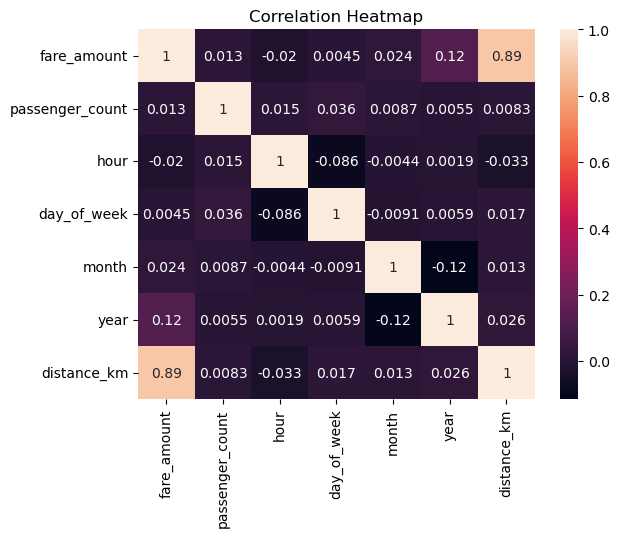

In [258]:
# a heatmap showing the correlation of all the variables

import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap
sns. heatmap(correlation_table,annot=True)
plt.title('Correlation Heatmap')
plt.show()

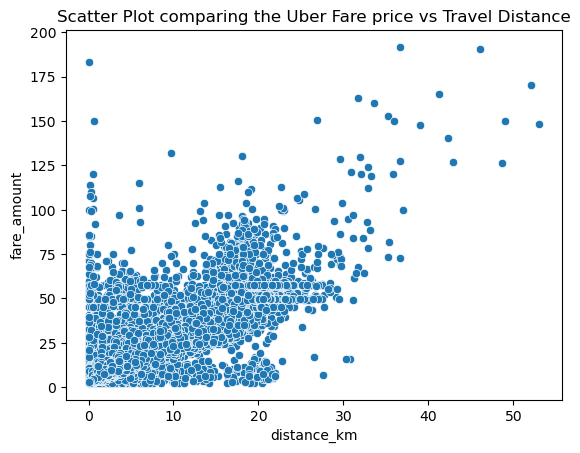

In [261]:
# The key relationship
sns.scatterplot(x='distance_km',y='fare_amount',data=df1)
plt.title('Scatter Plot comparing the Uber Fare price vs Travel Distance')
plt.show()

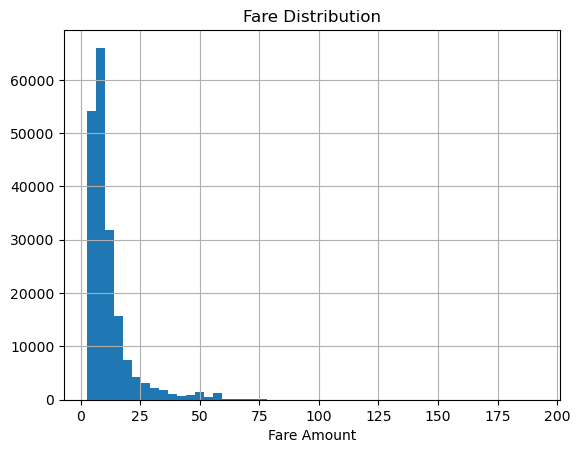

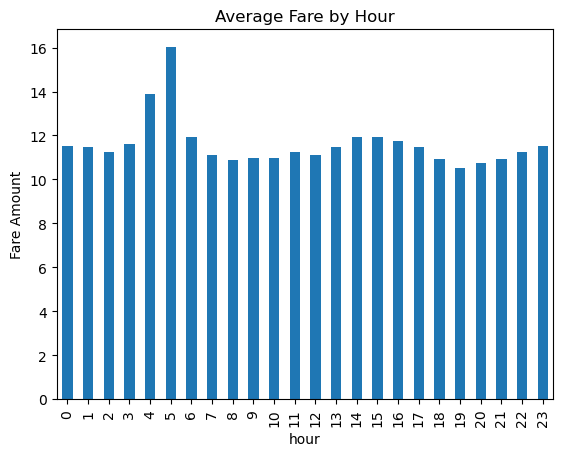

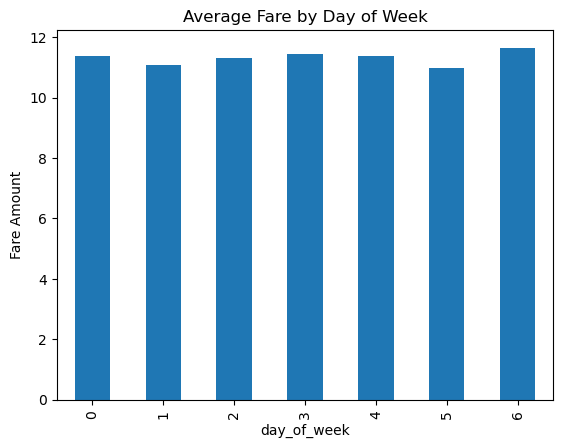

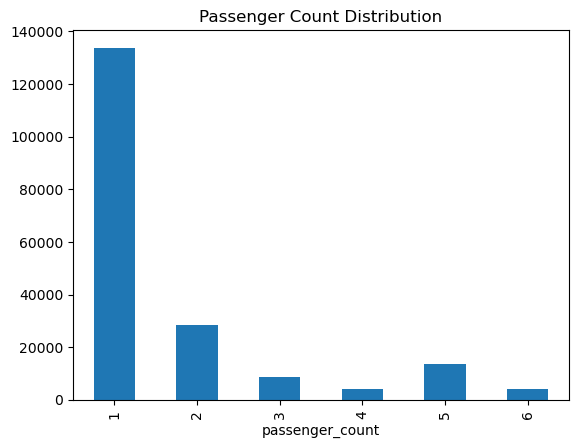

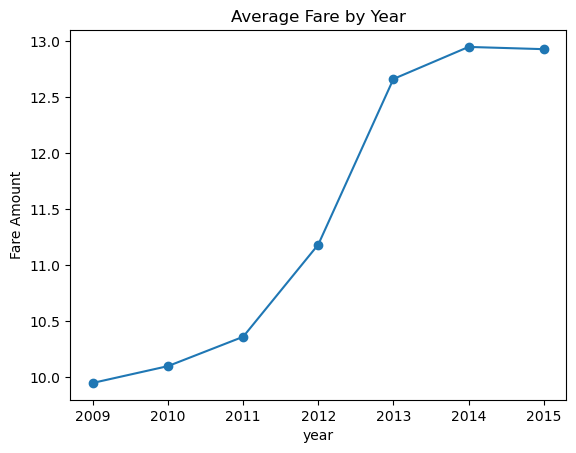

In [262]:
# Fare distribution
df1['fare_amount'].hist(bins=50)
plt.xlabel('Fare Amount')
plt.title('Fare Distribution')
plt.show()

# Average fare by hour
df1.groupby('hour')['fare_amount'].mean().plot(kind='bar')
plt.title('Average Fare by Hour')
plt.ylabel('Fare Amount')
plt.show()

# Average fare by day of week
df1.groupby('day_of_week')['fare_amount'].mean().plot(kind='bar')
plt.title('Average Fare by Day of Week')
plt.ylabel('Fare Amount')
plt.show()

# Passenger count distribution
df1['passenger_count'].value_counts().sort_index().plot(kind='bar')
plt.title('Passenger Count Distribution')
plt.show()

# Fare trend over years
df1.groupby('year')['fare_amount'].mean().plot(kind='line', marker='o')
plt.title('Average Fare by Year')
plt.ylabel('Fare Amount')
plt.show()

# Model Development

In [270]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [281]:
y=df1[['fare_amount']]
x=df1[['distance_km']]


In [282]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=38)
model=LinearRegression()
model.fit(x_train,y_train)
prediction=model.predict(x_test)


In [285]:
from sklearn.metrics import r2_score, mean_squared_error

print('R²:', r2_score(y_test, prediction))
print('RMSE:', np.sqrt(mean_squared_error(y_test, prediction)))

R²: 0.7969914721882133
RMSE: 4.326885113955371
